In [103]:
import os

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
import scanpy as sc
from scipy import stats
import statsmodels.formula.api as smf

import cellspec as spc

%matplotlib inline

In [2]:
colors = [
    '#FF1B5E',  # coral
    '#FFDB57',  # yellow
    '#438CFD',  # blue
    '#FF8C00',  # orange
    '#80F15E',  # lime green
    '#03FFFF',  # cyan
    '#5941A9',  # purple
    '#E980FC',  # magenta
    '#1A1A2E',  # navy
    '#F5F0FF',  # lavender white
    '#C17F3E',  # amber brown
]

pal = {
    "AAVS_Clone_4_P1":colors[2],
    "AAVS_Clone_4_P2":colors[2],
    "AAVS_Clone_4_P3":colors[2],
    "AAVS_Clone_5_P1":colors[4],
    "AAVS_Clone_5_P2":colors[4],
    "AAVS_Clone_5_P3":colors[4],
    "AAVS_Clone_6_P1":colors[6],
    "AAVS_Clone_6_P2":colors[6],
    "AAVS_Clone_6_P3":colors[6],
    "PolE_Clone_4_P1":colors[0],
    "PolE_Clone_4_P2":colors[0],
    "PolE_Clone_4_P3":colors[0],
    "PolE_Clone_5_P1":colors[1],
    "PolE_Clone_5_P2":colors[1],
    "PolE_Clone_6_P1":colors[1],
    "PolE_Clone_6_P2":colors[3],
    "PolE_Clone_6_P3":colors[3]
}

In [3]:
# sns.set_style("white", {"axes.facecolor": (0, 0, 0, 0)}) 
# plt.style.use("dark_background")

In [4]:
import matplotlib.font_manager as fm
import os, glob


fm._load_fontmanager(try_read_cache=False)
# Register TeX Gyre Heros if present
for f in glob.glob(os.path.expanduser("~/.local/share/fonts/texgyreheros*.otf")):
    fm.fontManager.addfont(f)

In [5]:
mpl.rcParams.update({
    # Font
    "font.family": "sans-serif",
    "font.sans-serif": ["TeX Gyre Heros"],
    "font.size": 12,

    # Axes lines
    "axes.linewidth": 1.5,

    # Tick marks
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,

    # Tick direction (outward is common in publications)
    "xtick.direction": "out",
    "ytick.direction": "out",
})

# K562 Proliferation Data

data collected by Ian: [notion](https://www.notion.so/srivatsan-lab/PolE-K562-growth-rate-32ef40695c9580af8eb0ca58fd08d54f?source=copy_link)

In [7]:
cols = ['clone','Mutation',0,5,7,10]

WT = {
    'WT_clone1_rep1':['1','WT',3000,1.23e5,8.27e5,1.44e6],
    'WT_clone1_rep2':['1','WT',3000,1.11e5,1.30e6,1.82e6],
    'WT_clone2_rep1':['2','WT',3000,3.28e5,3.69e5,1.84e6],
    'WT_clone2_rep2':['2','WT',3000,1.11e5,6.98e5,8.21e5],
    'WT_clone3_rep1':['3','WT',3000,3.52e5,1.71e6,1.34e6],
    'WT_clone3_rep4':['3','WT',3000,5.04e5,1.52e6,2.38e6],
}

WT = pd.DataFrame.from_dict(WT,orient='index',columns=cols)

P286R = {
    'P286R_clone1_rep1':['1','P286R',3000,2.70e5,7.57e5,7.98e5],
    'P286R_clone1_rep2':['1','P286R',3000,7.04e4,3.17e5,9.21e5],
    'P286R_clone2_rep1':['2','P286R',3000,1.17e4,5.86e4,4.69e5],
    'P286R_clone2_rep2':['2','P286R',3000,2.93e4,3.52e4,8.33e5],
    'P286R_clone3_rep1':['3','P286R',3000,3.52e4,7.62e4,1.51e6],
    'P286R_clone3_rep2':['3','P286R',3000,7.03e4,6.54e4,7.21e5],
}

P286R = pd.DataFrame.from_dict(P286R,orient='index',columns=cols)


prolif = pd.concat([WT, P286R])

timepoints = np.array([0, 5, 7, 10])

In [8]:
# Melt wide -> long format for seaborn
prolif_long = prolif.melt(
    id_vars=['clone', 'Mutation'],
    value_vars=[0, 5, 7, 10],
    var_name='Day',
    value_name='Cell Count'
)

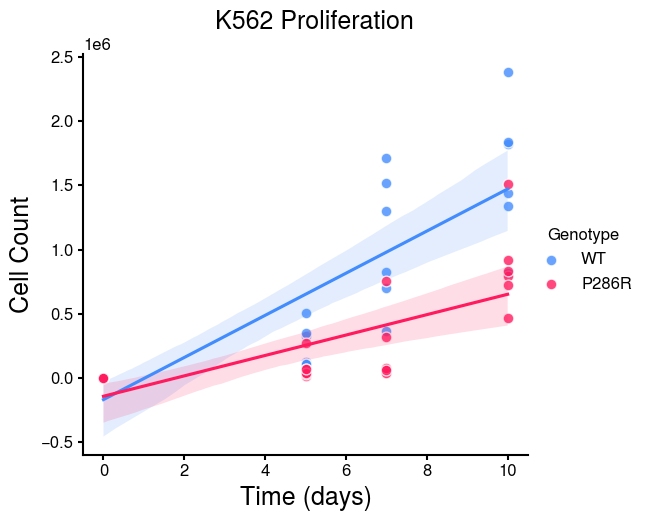

In [9]:
prolif_long['Day'] = pd.to_numeric(prolif_long['Day'])
prolif_long['Cell Count'] = pd.to_numeric(prolif_long['Cell Count'])
 
g = sns.lmplot(
    data=prolif_long,
    x='Day',
    y='Cell Count',
    hue='Mutation',
    # palette={'WT':'#E8E4F0','P286R':'#FF1B5E'}, # dark mode
    palette={'WT':'#438CFD','P286R':'#FF1B5E'},
    # markers=['o', 'X'],
    scatter_kws={'s': 60,'edgecolor': 'white'},
    height=5,
    aspect=1.1,
    ci=95,
    # legend=False
)
 
# g.set_axis_labels('Day', 'Cell Count')

plt.xlabel("Time (days)", fontsize=18)
plt.ylabel("Cell Count", fontsize=18)

g.figure.suptitle('K562 Proliferation',size=18, y=1.02)

g._legend.set_title('Genotype')

In [10]:
# =========================================================================
#    Log-linear regression: ln(N) = ln(N0) + r*t
#    Slope = r (ln-fold/day), r/ln2 = doublings/day
# =========================================================================
reg_rows = []
for sample, row in prolif.iterrows():
    counts = np.array([row[t] for t in timepoints], dtype=float)
    # Use all timepoints where count > 0
    mask = counts > 0
    t_fit = timepoints[mask]
    ln_counts = np.log(counts[mask])
    slope, intercept, r_value, p_value, std_err = stats.linregress(t_fit, ln_counts)
    reg_rows.append({
        'sample': sample,
        'clone': row['clone'],
        'Mutation': row['Mutation'],
        'r_per_day': slope,
        'doublings_per_day': slope / np.log(2),
        'r_squared': r_value**2,
        'p_value': p_value,
        'std_err': std_err,
    })
df_reg = pd.DataFrame(reg_rows)

In [11]:
print("\n" + "=" * 80)
print("LOG-LINEAR REGRESSION (all timepoints)")
print("   ln(N) ~ r * t + intercept")
print("=" * 80)
print(df_reg.to_string(index=False))


LOG-LINEAR REGRESSION (all timepoints)
   ln(N) ~ r * t + intercept
           sample clone Mutation  r_per_day  doublings_per_day  r_squared  p_value  std_err
   WT_clone1_rep1     1       WT   0.648189           0.935140   0.952912 0.023828 0.101887
   WT_clone1_rep2     1       WT   0.681844           0.983692   0.939076 0.030941 0.122805
   WT_clone2_rep1     2       WT   0.636909           0.918865   0.935108 0.032990 0.118639
   WT_clone2_rep2     2       WT   0.596652           0.860787   0.924414 0.038535 0.120641
   WT_clone3_rep1     3       WT   0.652719           0.941674   0.863906 0.070535 0.183188
   WT_clone3_rep4     3       WT   0.694772           1.002344   0.902077 0.050222 0.161863
P286R_clone1_rep1     1    P286R   0.588150           0.848521   0.870417 0.067039 0.160466
P286R_clone1_rep2     1    P286R   0.588367           0.848834   0.985278 0.007388 0.050856
P286R_clone2_rep1     2    P286R   0.500220           0.721665   0.934683 0.033210 0.093503
P286R_clone

In [12]:
# =========================================================================
# SIMPLE 6-REP SUMMARY + WELCH'S T-TEST
# Treating each replicate as independent (n=6 per genotype)
# =========================================================================
print("\n" + "=" * 80)
print("SIMPLE SUMMARY: 6 replicates per genotype (pooling across clones)")
print("=" * 80)
 
for mut in ['WT', 'P286R']:
    vals = df_reg.loc[df_reg['Mutation'] == mut, 'r_per_day'].values
    n = len(vals)
    m = vals.mean()
    s = vals.std(ddof=1)
    sem = s / np.sqrt(n)
    ci95 = sem * stats.t.ppf(0.975, df=n - 1)
    print(f"\n{mut} (n={n}):")
    print(f"  mean r    = {m:.4f} ln-fold/day  ({m / np.log(2):.4f} doublings/day)")
    print(f"  std       = {s:.4f}")
    print(f"  SEM       = {sem:.4f}")
    print(f"  95% CI    = [{m - ci95:.4f}, {m + ci95:.4f}]")
 
wt_r = df_reg.loc[df_reg['Mutation'] == 'WT', 'r_per_day'].values
p286r_r = df_reg.loc[df_reg['Mutation'] == 'P286R', 'r_per_day'].values
t_stat, p_val = stats.ttest_ind(wt_r, p286r_r, equal_var=False)
diff = wt_r.mean() - p286r_r.mean()
print(f"\nWelch's t-test: t = {t_stat:.3f}, p = {p_val:.4f}")
print(f"Difference in means: {diff:.4f} ln-fold/day ({diff / np.log(2):.4f} doublings/day)")


SIMPLE SUMMARY: 6 replicates per genotype (pooling across clones)

WT (n=6):
  mean r    = 0.6518 ln-fold/day  (0.9404 doublings/day)
  std       = 0.0347
  SEM       = 0.0142
  95% CI    = [0.6154, 0.6883]

P286R (n=6):
  mean r    = 0.5537 ln-fold/day  (0.7988 doublings/day)
  std       = 0.0420
  SEM       = 0.0171
  95% CI    = [0.5096, 0.5977]

Welch's t-test: t = 4.415, p = 0.0014
Difference in means: 0.0982 ln-fold/day (0.1416 doublings/day)


- **Days 0–14:** Single cell → ~3,000 cells in 96-well (fixed, 1.5 weeks)
- **Days 14-21:** 3,000 cells in 6-well → harvest

For P286R, Phase 1 doublings were fixed at log₂(3000) ≈ 11.6, reflecting the minimum cell count at transfer. For WT, Phase 1 doublings were estimated by scaling the P286R value by the ratio of measured growth rates (WT/P286R = 1.18), yielding 13.6 doublings and an implied ~12,400 cells at transfer. Phase 2 doublings were computed as the product of the growth rate and 7-day duration. Uncertainties were propagated from the 95% CI on growth rates; for WT Phase 1, uncertainty on the rate ratio was estimated via the delta method and combined in quadrature with Phase 2 uncertainty. Total doublings per passage were 20.2 (95% CI: 18.8–21.6) for WT and 17.1 (95% CI: 16.7–17.6) for P286R.

In [26]:
doublings_per_passage = {
    'WT':[20.2,1.4],
    'P286R':[17.1,0.4]
}

# Load Data

In [7]:
adata = spc.pp.load_vcf('../data/K562_mut_accumulation/K562_mut_accumulation_joint.vcf.gz')
adata

Loading VCF: 7596561 sites [03:34, 35420.66 sites/s]


Building matrices for 7596561 sites × 17 samples...
Converting to sparse format...
Done! Loaded 7596561 sites × 17 samples


AnnData object with n_obs × n_vars = 17 × 7596561
    var: 'chrom', 'pos'
    uns: 'vcf_source', 'n_variants', 'n_cells'
    layers: 'DP', 'AD'

### Save adata for fast reloading:

In [8]:
# adata.write_h5ad('../results/K562_mut_accumulation/K562_mut_accumulation_raw.h5ad')

### Load adata from h5ad

In [73]:
adata = ad.read_h5ad('../results/K562_mut_accumulation/K562_mut_accumulation_raw.h5ad')

### Setup

In [74]:
obs = {
    "AAVS_Clone_4_P1":["WT","C4",1],
    "AAVS_Clone_4_P2":["WT","C4",2],
    "AAVS_Clone_4_P3":["WT","C4",3],
    "AAVS_Clone_5_P1":["WT","C5",1],
    "AAVS_Clone_5_P2":["WT","C5",2],
    "AAVS_Clone_5_P3":["WT","C5",3],
    "AAVS_Clone_6_P1":["WT","C6",1],
    "AAVS_Clone_6_P2":["WT","C6",2],
    "AAVS_Clone_6_P3":["WT","C6",3],
    "PolE_Clone_4_P1":["P286R","C4",1],
    "PolE_Clone_4_P2":["P286R","C4",2],
    "PolE_Clone_4_P3":["P286R","C4",3],
    "PolE_Clone_5_P1":["P286R","C5",1],
    "PolE_Clone_5_P2":["P286R","C5",2],
    "PolE_Clone_6_P1":["P286R","C6",1],
    "PolE_Clone_6_P2":["P286R","C6",2],
    "PolE_Clone_6_P3":["P286R","C6",3],
}
adata.obs = pd.DataFrame.from_dict(obs, orient='index', columns=['Mutation','Replicate','Split'])

In [75]:
## Filter out non snps
spc.pp.filter_to_snps(adata, inplace=True)

In [76]:
spc.pp.annotate_contexts(adata, fasta_path='/shared/biodata/reference/GATK/hg38/Homo_sapiens_assembly38.fasta')
adata.var

Annotating trinuc contexts: 100%|██████████| 5606780/5606780 [01:04<00:00, 86506.63 sites/s]


,chrom,pos,anc,der,trinuc_type
chr1-10164-A>T,chr1,10164,TAA,TTA,TTA>TAA
chr1-10177-A>C,chr1,10177,AAC,ACC,GTT>GGT
chr1-10247-T>C,chr1,10247,CTA,CCA,CTA>CCA
chr1-10250-A>C,chr1,10250,AAC,ACC,GTT>GGT
chr1-10257-A>C,chr1,10257,AAC,ACC,GTT>GGT
...,...,...,...,...,...
chrY-56887491-C>A,chrY,56887491,CCT,CAT,CCT>CAT
chrY-56887503-G>T,chrY,56887503,GGG,GTG,CCC>CAC
chrY-56887530-A>C,chrY,56887530,CAT,CCT,ATG>AGG
chrY-56887837-G>A,chrY,56887837,AGA,AAA,TCT>TTT


# Basic Stats
- depth
- mutations per sample
- VAF in bulk

In [77]:
adata.var['tot_depth_bulk'] = np.ravel(adata.layers['DP'].sum(axis=0))

Text(0, 0.5, 'Count of Sites')

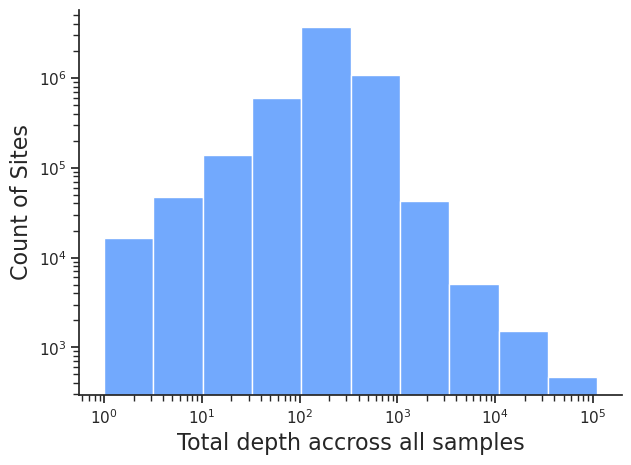

In [78]:
sns.set_theme(style="ticks")
f, ax = plt.subplots(figsize=(7, 5))
sns.despine(f)
sns.histplot(adata.var, x='tot_depth_bulk', 
             alpha=0.75,
             color = colors[2],
             linewidth=1,
             ax=ax,
             log_scale=True,
             bins=10
            )
ax.set_yscale('log')
plt.xlabel("Total depth accross all samples", fontsize=16)
plt.ylabel("Count of Sites", fontsize=16)


In [79]:
spc.tl.compute_bulk_vaf(adata,
                        target_dp=100
                       )

Text(0, 0.5, 'Count of Sites')

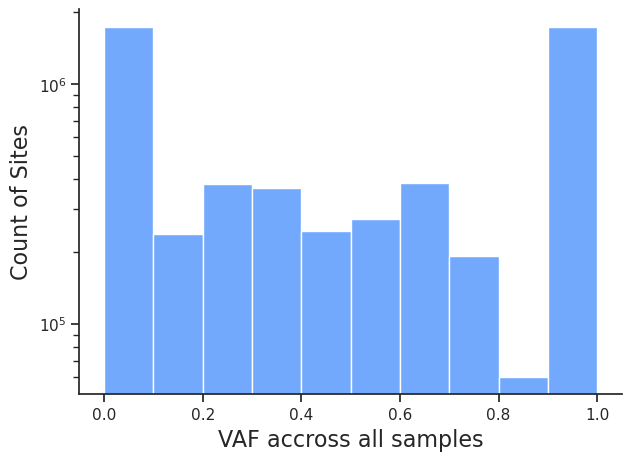

In [80]:
sns.set_theme(style="ticks")
f, ax = plt.subplots(figsize=(7, 5))
sns.despine(f)
sns.histplot(adata.var, x='bulk_vaf', 
             alpha=0.75,
             color = colors[2],
             linewidth=1,
             ax=ax,
             # log_scale=True,
             bins=10
            )
ax.set_yscale('log')
plt.xlabel("VAF accross all samples", fontsize=16)
plt.ylabel("Count of Sites", fontsize=16)

### Filtering

In [81]:
# Filter out sites without sufficient coverage in all samples
spc.pp.filter_by_coverage(adata, min_depth=10)

# Filter out singletons
# spc.pp.filter_by_coverage(adata, min_depth=2, layer='AD')

## Filter out high VAF (ancestral) SNPs (reflecting triploidy)
adata = adata[:,adata.var['bulk_vaf']<0.5].copy()

In [82]:
adata

AnnData object with n_obs × n_vars = 17 × 558148
    obs: 'Mutation', 'Replicate', 'Split'
    var: 'chrom', 'pos', 'anc', 'der', 'trinuc_type', 'tot_depth_bulk', 'bulk_vaf'
    uns: 'n_cells', 'n_variants', 'vcf_source'
    layers: 'AD', 'DP'

# Per Sample VAF

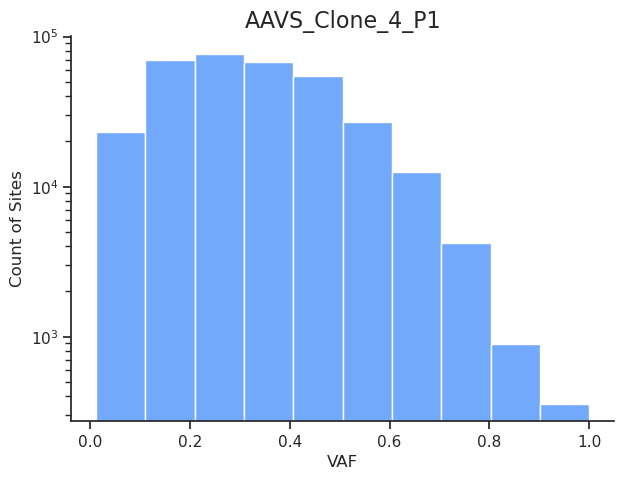

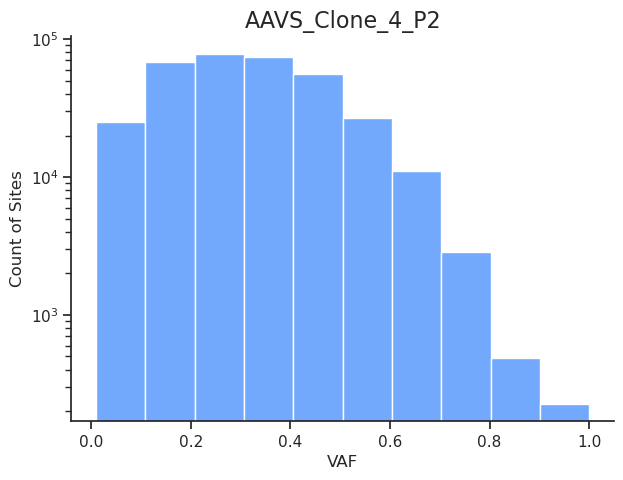

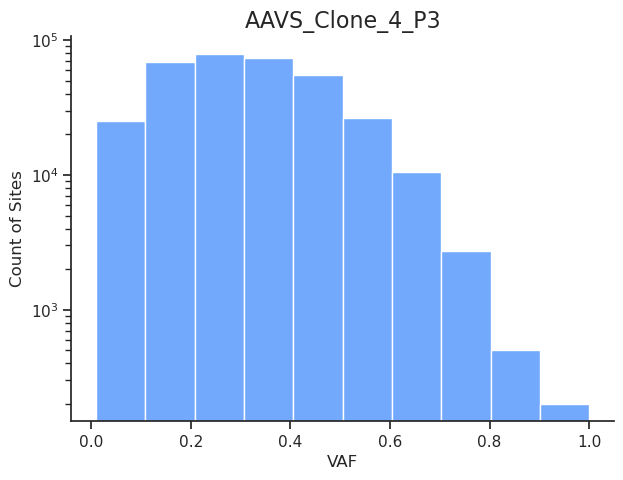

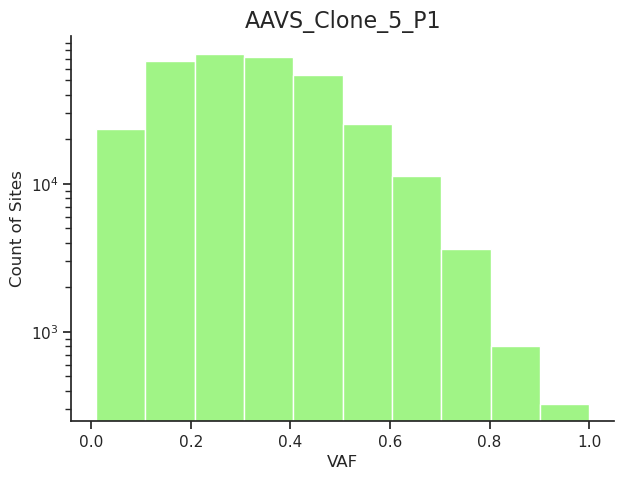

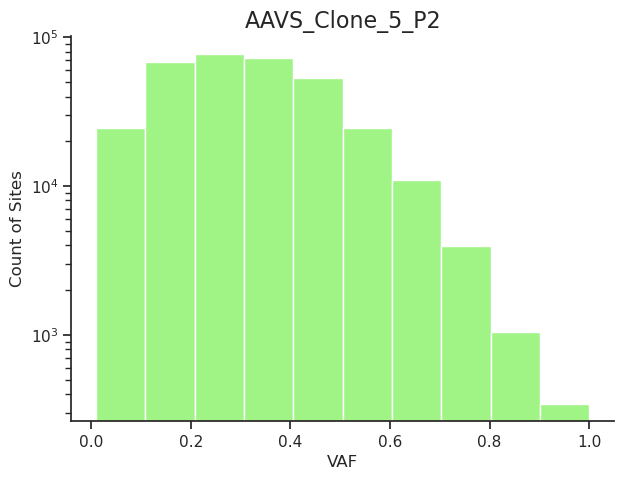

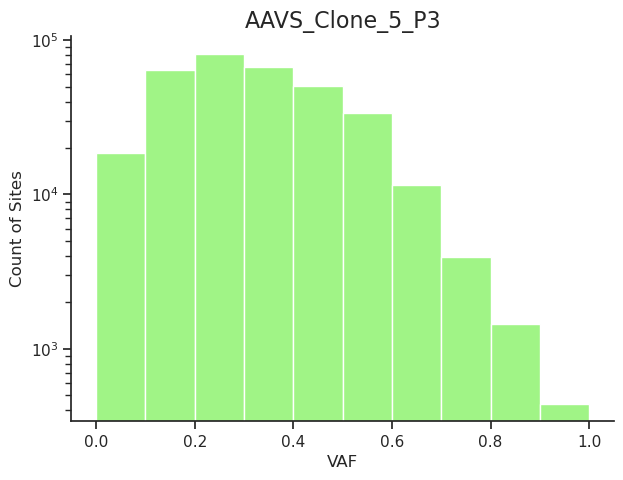

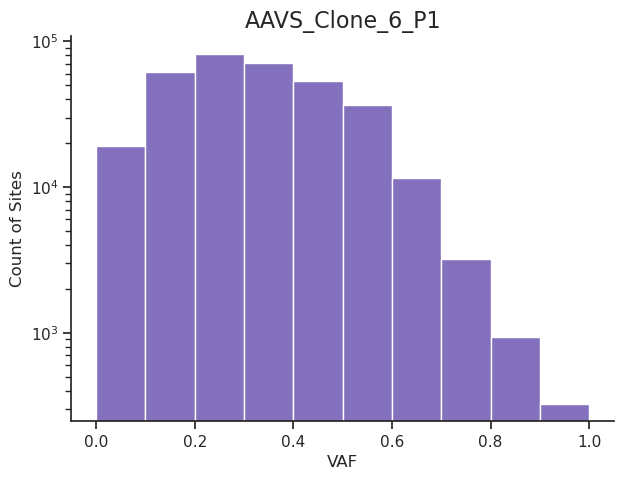

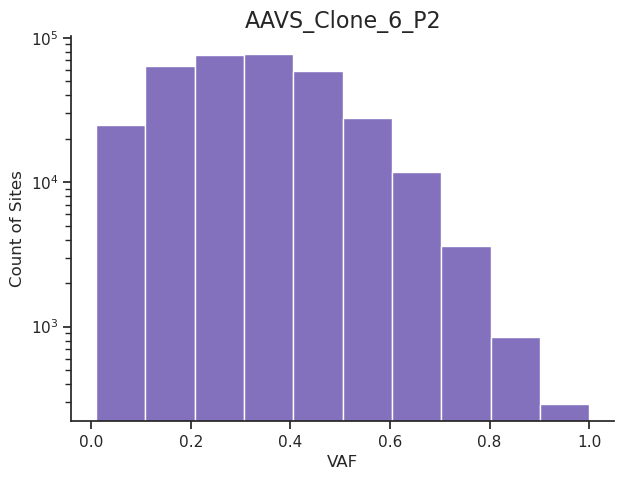

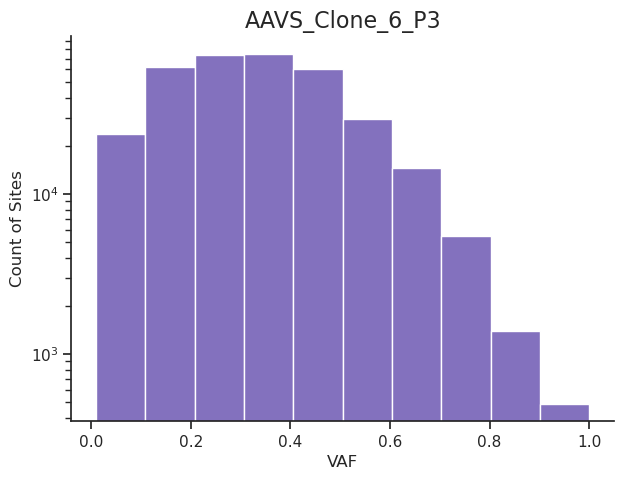

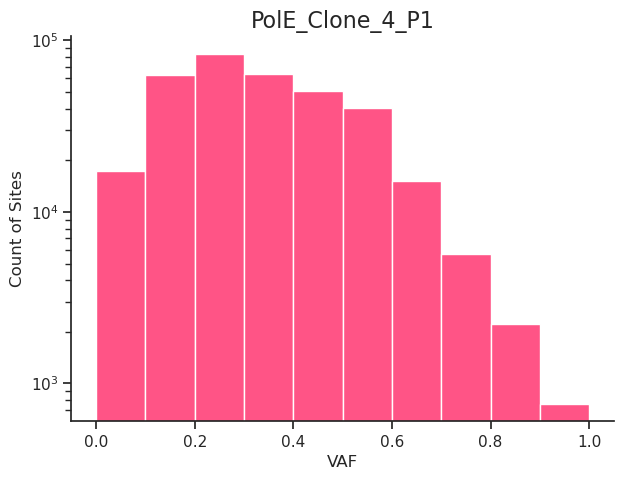

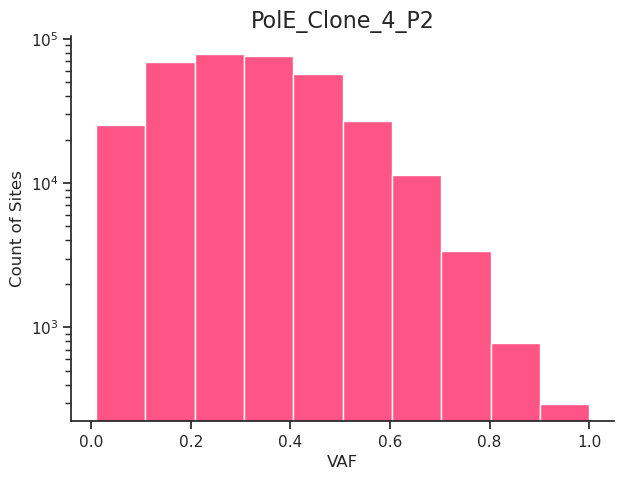

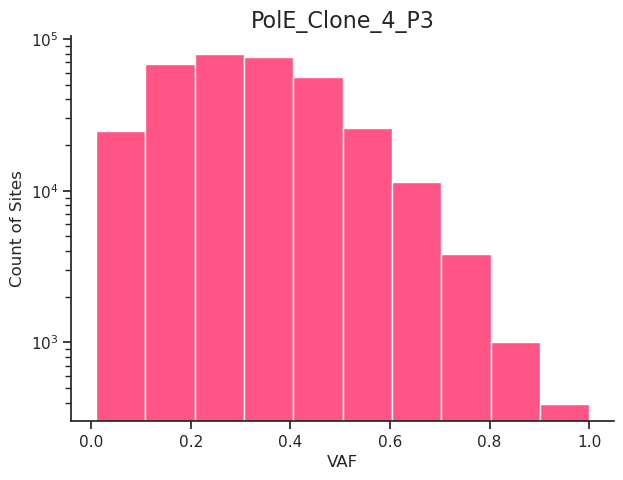

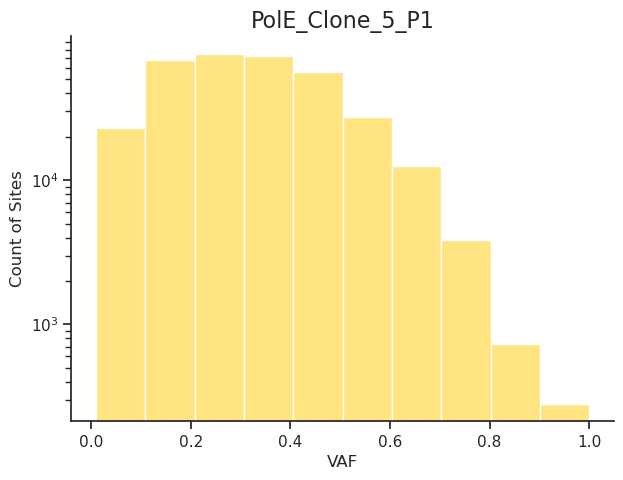

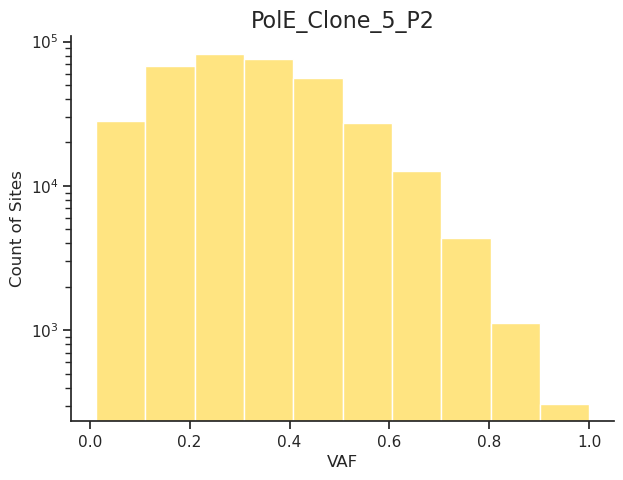

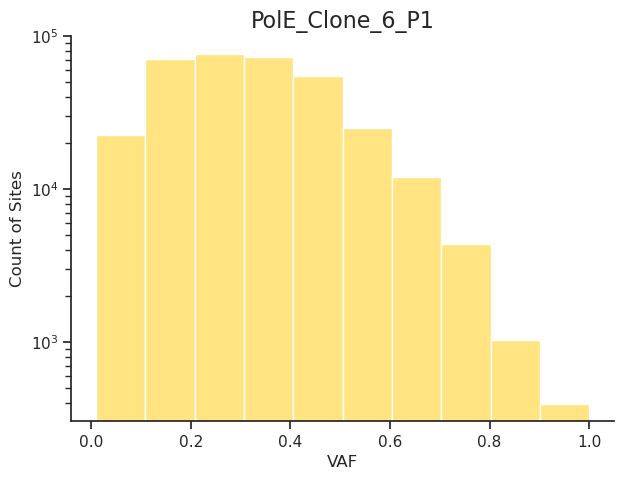

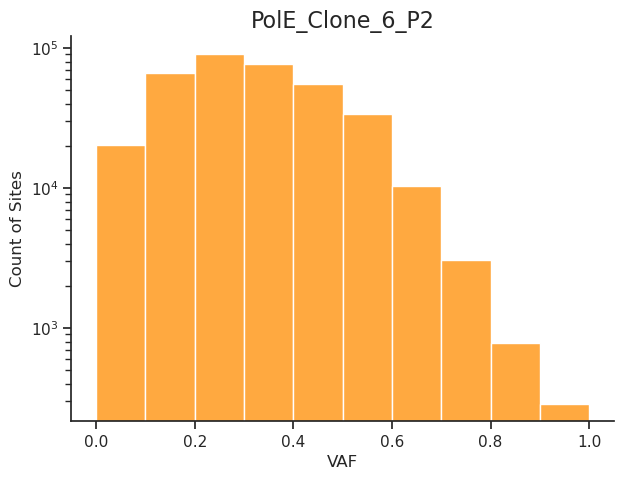

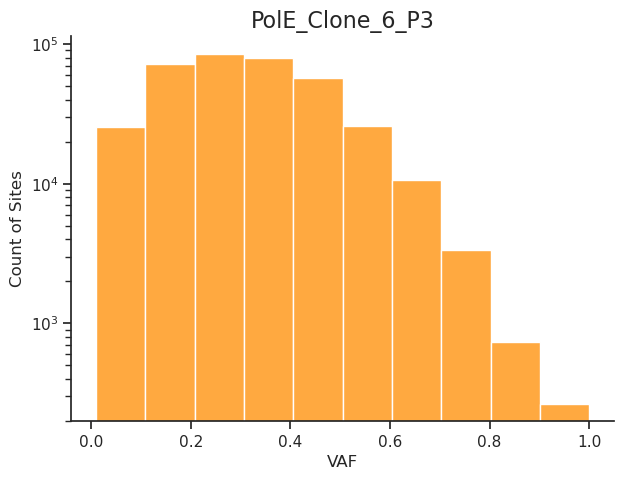

In [83]:
for sample in adata.obs.index:
    sub = adata[sample,:].copy()
    
    vaf = spc.utils.context.compute_vaf(sub.layers['AD'].toarray()[0],sub.layers['DP'].toarray()[0],100)
    
    high_vaf=vaf>0.15
    
    adata.var[f"{sample}_high_vaf"]=high_vaf
    
    sub.var['vaf'] = vaf
    
    sub = sub[:,sub.layers['AD']>0]
    
    sns.set_theme(style="ticks")
    f, ax = plt.subplots(figsize=(7, 5))
    sns.despine(f)
    sns.histplot(sub.var, x='vaf', 
                 alpha=0.75,
                 color = pal[sample],
                 # edgecolor=".3",
                 linewidth=1,
                 ax=ax,
                 # log_scale=True,
                 bins=10
                )
    ax.set_yscale('log')
    plt.xlabel("VAF", fontsize=12)
    plt.ylabel("Count of Sites", fontsize=12)
    plt.title(sample, fontsize=16)
    plt.show()

In [84]:
count = {}
for sample in adata.obs.index:
    count[sample] = adata.var[f'{sample}_high_vaf'].sum()
    
adata.obs['high_vaf_count'] = adata.obs.index.map(count)

/loc/scratch/49617674/ipykernel_4050/3263542288.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=adata.obs, x=adata.obs.index, y='high_vaf_count', palette=pal)


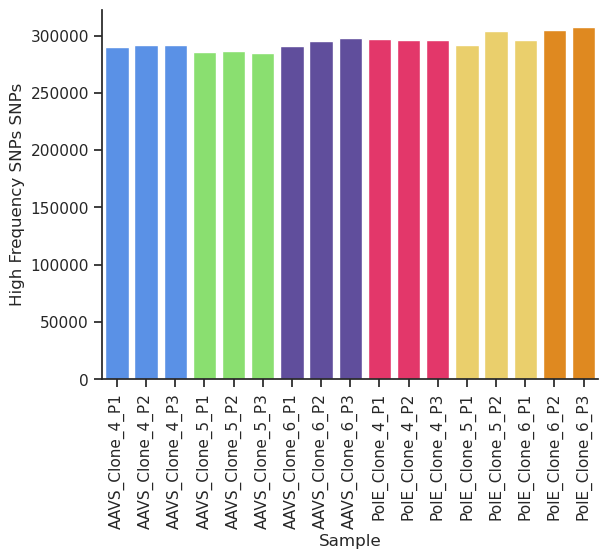

In [85]:
sns.barplot(data=adata.obs, x=adata.obs.index, y='high_vaf_count', palette=pal)
plt.xlabel("Sample", fontsize=12)
plt.ylabel("High Frequency SNPs SNPs", fontsize=12)
plt.xticks(rotation=90)
sns.despine()

# Mutation Spectrum

In [86]:
spc.tl.compute_spectrum(adata)

Computing spectrum (key='spectrum'): 100%|██████████| 17/17 [00:04<00:00,  4.12cell/s]


,ACA>AAA,ACC>AAC,ACG>AAG,ACT>AAT,CCA>CAA,CCC>CAC,CCG>CAG,CCT>CAT,GCA>GAA,GCC>GAC,...,CTG>CGG,CTT>CGT,GTA>GGA,GTC>GGC,GTG>GGG,GTT>GGT,TTA>TGA,TTC>TGC,TTG>TGG,TTT>TGT
AAVS_Clone_4_P1,3396,2824,1316,2176,3198,2585,1328,2534,2912,2043,...,1600,1435,1173,1116,2140,1800,1390,1733,2220,2793
AAVS_Clone_4_P2,3515,2862,1357,2171,3225,2593,1311,2607,2929,2044,...,1640,1462,1156,1163,2174,1881,1405,1768,2257,2867
AAVS_Clone_4_P3,3482,2871,1367,2190,3208,2557,1326,2564,2998,2043,...,1641,1451,1176,1167,2112,1879,1416,1725,2275,2838
AAVS_Clone_5_P1,3371,2837,1332,2169,3123,2526,1265,2496,2911,2037,...,1553,1394,1159,1118,2111,1786,1369,1710,2196,2788
AAVS_Clone_5_P2,3466,2833,1338,2185,3145,2520,1287,2577,2909,2054,...,1633,1419,1171,1121,2119,1839,1382,1725,2211,2795
AAVS_Clone_5_P3,3379,2826,1317,2113,3176,2525,1274,2490,2880,2015,...,1610,1407,1136,1136,2088,1778,1368,1708,2226,2799
AAVS_Clone_6_P1,3444,2849,1350,2142,3163,2519,1309,2516,2933,2037,...,1635,1424,1165,1161,2098,1842,1366,1721,2220,2816
AAVS_Clone_6_P2,3478,2913,1371,2200,3251,2605,1335,2526,2980,2081,...,1629,1471,1186,1167,2144,1867,1392,1773,2272,2878
AAVS_Clone_6_P3,3512,2903,1382,2192,3193,2593,1333,2516,2975,2066,...,1642,1468,1178,1186,2139,1866,1411,1755,2292,2885
PolE_Clone_4_P1,3407,2851,1366,2264,3171,2534,1304,2833,2922,2040,...,1645,1592,1168,1159,2095,1842,1426,1758,2218,3338


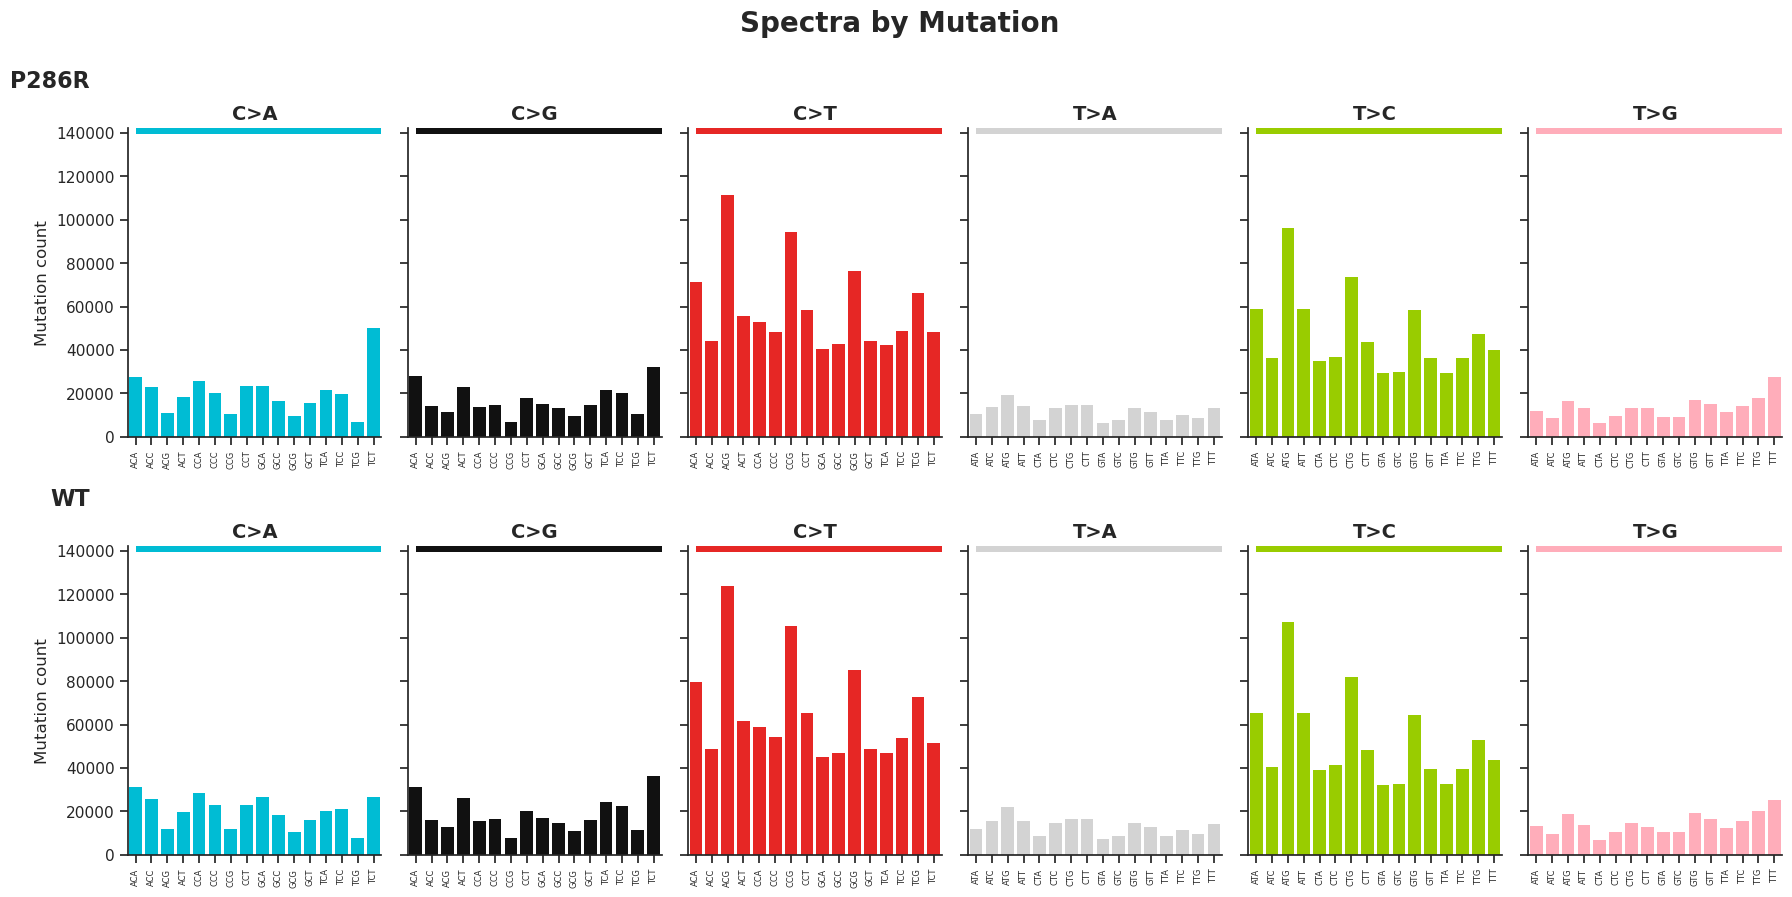

In [87]:
spc.pl.spectrum(adata, groupby='Mutation', figsize=(18,9), transparent=True,
                # outdir='../results/K562_mut_accumulation/'
               )


# Signature Decomposition

### Grouped

In [88]:
spc.tl.fit_cosmic_signatures(adata, groupby='Mutation', output_dir='../results/K562_mut_accumulation/sigprofiler')

Fitting COSMIC v3.4 signatures to spectrum 'spectrum'...
Aggregating spectrum by 'Mutation' using sum...
Created 2 aggregated samples from 2 unique groups
SigProfiler outputs will be saved to: ../results/K562_mut_accumulation/sigprofiler
Converted spectrum to SigProfiler format: ../results/K562_mut_accumulation/sigprofiler/input/matrix.txt
Analyzing 2 samples with 5619621 total mutations
Running SigProfilerAssignment (this may take a few minutes)...
Assigning COSMIC sigs or Signature Database ...... 





                                        ################ Sample 1 #################
############################# Initial Composition #################################### 
       SBS1    SBS2  SBS3     SBS4      SBS5     SBS6  SBS7a  SBS7b  SBS7c  \
0  213930.0  1812.0   0.0  45435.0  692236.0  50952.0    0.0    0.0    0.0   

    SBS7d  ...  SBS90  SBS91  SBS92  SBS93  SBS94  SBS95    SBS96   SBS97  \
0  3466.0  ...    0.0    0.0    0.0    0.0    0.0    0.0  92920.0  6573.0   

     

[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:   10.0s finished




 
Your Job Is Successfully Completed! Thank You For Using SigProfilerAssignment.
 
Parsing results...
Found 38 active signatures across 2 samples
Results stored in:
  - adata.uns['spectrum_Mutation_cosmic_fit']
  - adata.uns['spectrum_Mutation_cosmic_fit_proportions']
  - adata.uns['spectrum_Mutation_cosmic_fit_metadata']
  - adata.uns['cosmic_signatures']


In [89]:
adata.uns['spectrum_Mutation_cosmic_fit_proportions'].loc['P286R'].sort_values(ascending=False)[:15]

SBS5     0.257974
SBS54    0.087848
SBS1     0.079725
SBS39    0.076939
SBS37    0.074778
SBS46    0.052351
SBS30    0.044480
SBS32    0.043297
SBS96    0.034628
SBS19    0.027581
SBS87    0.025340
SBS8     0.019011
SBS6     0.018988
SBS4     0.016932
SBS29    0.015076
Name: P286R, dtype: float64

### Individual

In [90]:
spc.tl.fit_cosmic_signatures(adata, output_dir='../results/K562_mut_accumulation/sigprofiler_ind')

Fitting COSMIC v3.4 signatures to spectrum 'spectrum'...
SigProfiler outputs will be saved to: ../results/K562_mut_accumulation/sigprofiler_ind
Converted spectrum to SigProfiler format: ../results/K562_mut_accumulation/sigprofiler_ind/input/matrix.txt
Analyzing 17 samples with 5619621 total mutations
Running SigProfilerAssignment (this may take a few minutes)...
Assigning COSMIC sigs or Signature Database ...... 





                                        ################ Sample 1 #################
############################# Initial Composition #################################### 
      SBS1   SBS2  SBS3    SBS4     SBS5    SBS6  SBS7a  SBS7b  SBS7c  SBS7d  \
0  25640.0  214.0   0.0  5524.0  79706.0  8178.0    0.0    0.0    0.0  238.0   

   ...  SBS90  SBS91  SBS92  SBS93  SBS94  SBS95    SBS96   SBS97   SBS98  \
0  ...    0.0    0.0    0.0    0.0    0.0    0.0  10753.0  1059.0  1922.0   

   SBS99  
0    0.0  

[1 rows x 86 columns]
L2%:  0.06795751167141298
###################

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:  1.4min
[Parallel(n_jobs=1)]: Done  17 out of  17 | elapsed:  1.4min finished




 
Your Job Is Successfully Completed! Thank You For Using SigProfilerAssignment.
 
Parsing results...
Found 42 active signatures across 17 samples
Results stored in:
  - adata.obsm['spectrum_cosmic_fit']
  - adata.obsm['spectrum_cosmic_fit_proportions']
  - adata.uns['spectrum_cosmic_fit_metadata']
  - adata.uns['cosmic_signatures']


In [91]:
## Plot SBS10a counts of individuals

# Mutation Accumulation

In [92]:
adata_10a = adata[:,adata.var['trinuc_type']=='TCT>TAT'].copy()

In [93]:
lineages = {
    'P286R_C4': ["PolE_Clone_4_P1","PolE_Clone_4_P2","PolE_Clone_4_P3"],
    'P286R_C5': ["PolE_Clone_5_P1","PolE_Clone_5_P2"],
    'P286R_C6': ["PolE_Clone_6_P1","PolE_Clone_6_P2","PolE_Clone_6_P3"],
    'WT_C4': ["AAVS_Clone_4_P1","AAVS_Clone_4_P2","AAVS_Clone_4_P3"],
    'WT_C5': ["AAVS_Clone_5_P1","AAVS_Clone_5_P2","AAVS_Clone_5_P3"],
    'WT_C6': ["AAVS_Clone_6_P1","AAVS_Clone_6_P2","AAVS_Clone_6_P3"],
}

In [94]:
def compute_accumulated_mutations(adata, lineages):
    """
    Compute accumulated mutations along lineage branches.
    
    Parameters
    ----------
    adata : AnnData
        AnnData object with genotype calls in .X (>0 = variant present)
    lineages : dict
        Dictionary mapping lineage names to lists of sample names, ordered by generation.
        The first sample is treated as G0/ancestor.
        e.g., {'P270R_P1': ['Pole-1_P0', 'Pole-1_P1G1', 'Pole-1_P1G2', 'Pole-1_P1G3']}
    
    Returns
    -------
    pd.DataFrame
        DataFrame with columns: Lineage, Split, Samples, Shared_Variants, Accumulated_Mutations
    """
    results = []
    
    for lineage_name, samples in lineages.items():
        samples = list(samples)
        
        # Each split point: from that generation onward
        split_points = []
        for i in range(len(samples)):
            remaining = samples[i:]
            split_points.append((i, remaining))
        
        # Compute shared variant counts
        shared_counts = {}
        sample_labels = {}
        for split_num, sample_set in split_points:
            subset = adata[sample_set, :]
            n_shared = np.ravel((subset.X > 0).sum(axis=0) == len(sample_set)).sum()
            shared_counts[split_num] = n_shared
            sample_labels[split_num] = sample_set
        
        # Compute accumulated (delta from baseline, which is split 0)
        baseline = shared_counts[0]
        for split_num in sorted(shared_counts.keys()):
            results.append({
                'Lineage': lineage_name,
                'Split': split_num,
                'Samples': sample_labels[split_num],
                'Shared_Variants': shared_counts[split_num],
                'Accumulated_Mutations': shared_counts[split_num] - baseline
            })
    
    return pd.DataFrame(results)

In [95]:
def cum_doublings(row):
    mut = row.Genotype
    split = row.Split
    return [doublings_per_passage[mut][0], doublings_per_passage[mut][1], doublings_per_passage[mut][0]*split,doublings_per_passage[mut][1]*split]

In [96]:
time_series = compute_accumulated_mutations(adata, lineages)
time_series = time_series.assign(
    Clone=lambda x: x['Lineage'].str.split('_').str[1],
    Genotype=lambda x: x['Lineage'].str.split('_').str[0]
)

In [99]:
time_series[['doublings_per_passage', 'doublings_per_passage_SE', 'cumulative_doublings', 'cumulative_doublings_SE']] = time_series.apply(cum_doublings, axis=1, result_type='expand')
# time_series

In [100]:
time_series['Accumulated_Mutations_norm'] = time_series_10a['Accumulated_Mutations'] / time_series_10a['doublings_per_passage']
time_series = time_series.fillna(0)

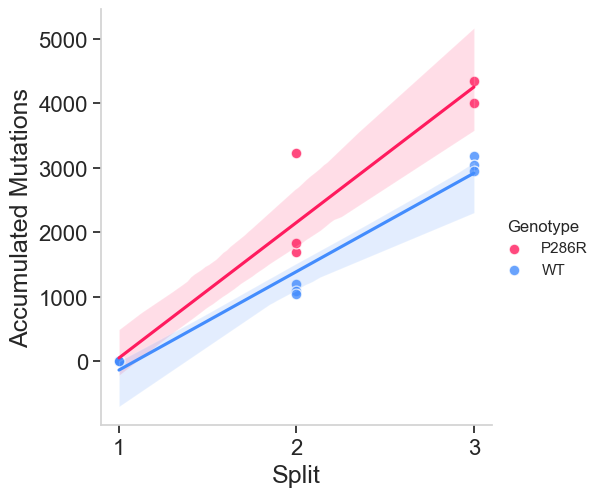

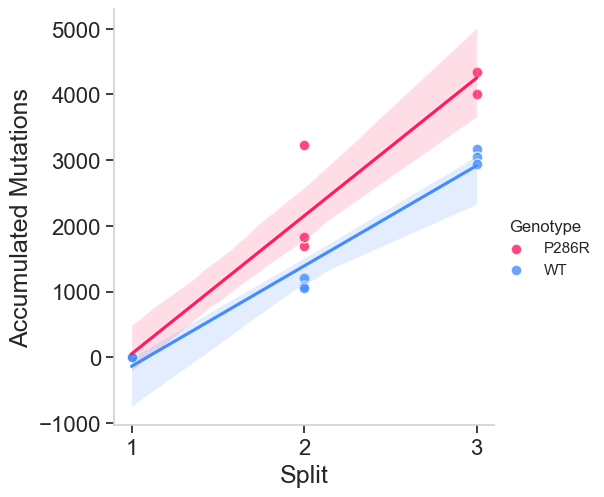

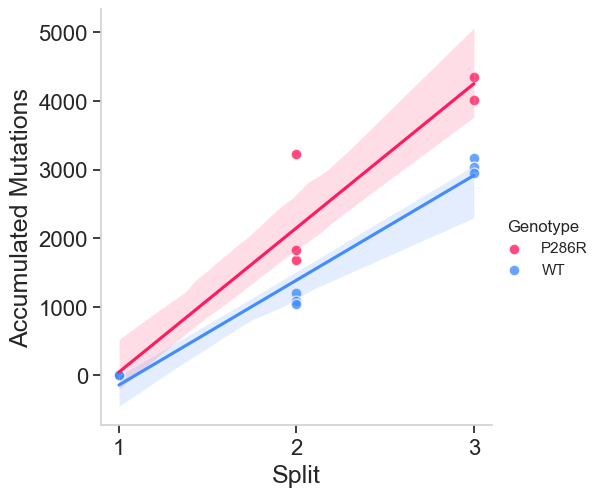

In [104]:
## Plot
g = sns.lmplot(time_series, x='Split',y='Accumulated_Mutations_norm',
               scatter_kws={'s': 60,'edgecolor': 'white'},
               # palette={'WT':'#E8E4F0','P286R':'#FF1B5E'}, #Dark mode
               palette={'WT':'#438CFD','P286R':'#FF1B5E'},
               hue='Genotype'
              )

new_ticks = [0,1,2]
new_labels = ['1','2','3']
g.set(xticks=new_ticks, xticklabels=new_labels)
g.ax.tick_params(labelsize=16)

# g.ax.legend(fontsize=16)
# # or to also control the title:
# leg = g.ax.get_legend()
# leg._legend_title_fontsize = 16
# for text in leg.get_texts():
#     text.set_fontsize(16)

# plt.ylim(-19000,100000)
plt.xlabel("Split", fontsize=18)
plt.ylabel("Accumulated Mutations", fontsize=18)
# plt.setp(g.spines.values(), linewidth=3)
# g.savefig('../results/K562_mut_accumulation/10a_accumulation.png', transparent=True, bbox_inches='tight')
plt.show()

In [105]:
time_series_10a = compute_accumulated_mutations(adata_10a, lineages)
time_series_10a = time_series_10a.assign(
    Clone=lambda x: x['Lineage'].str.split('_').str[1],
    Genotype=lambda x: x['Lineage'].str.split('_').str[0]
)

In [106]:
time_series_10a[['doublings_per_passage', 'doublings_per_passage_SE', 'cumulative_doublings', 'cumulative_doublings_SE']] = time_series_10a.apply(cum_doublings, axis=1, result_type='expand')
time_series_10a

,Lineage,Split,Samples,Shared_Variants,Accumulated_Mutations,Clone,Genotype,doublings_per_passage,doublings_per_passage_SE,cumulative_doublings,cumulative_doublings_SE
0,P286R_C4,0,"[PolE_Clone_4_P1, PolE_Clone_4_P2, PolE_Clone_...",2129,0,C4,P286R,17.1,0.4,0.0,0.0
1,P286R_C4,1,"[PolE_Clone_4_P2, PolE_Clone_4_P3]",3705,1576,C4,P286R,17.1,0.4,17.1,0.4
2,P286R_C4,2,[PolE_Clone_4_P3],4843,2714,C4,P286R,17.1,0.4,34.2,0.8
3,P286R_C5,0,"[PolE_Clone_5_P1, PolE_Clone_5_P2]",2426,0,C5,P286R,17.1,0.4,0.0,0.0
4,P286R_C5,1,[PolE_Clone_5_P2],7467,5041,C5,P286R,17.1,0.4,17.1,0.4
5,P286R_C6,0,"[PolE_Clone_6_P1, PolE_Clone_6_P2, PolE_Clone_...",4392,0,C6,P286R,17.1,0.4,0.0,0.0
6,P286R_C6,1,"[PolE_Clone_6_P2, PolE_Clone_6_P3]",7207,2815,C6,P286R,17.1,0.4,17.1,0.4
7,P286R_C6,2,[PolE_Clone_6_P3],9842,5450,C6,P286R,17.1,0.4,34.2,0.8
8,WT_C4,0,"[AAVS_Clone_4_P1, AAVS_Clone_4_P2, AAVS_Clone_...",2150,0,C4,WT,20.2,1.4,0.0,0.0
9,WT_C4,1,"[AAVS_Clone_4_P2, AAVS_Clone_4_P3]",2485,335,C4,WT,20.2,1.4,20.2,1.4


In [107]:
time_series_10a['Accumulated_Mutations_norm'] = time_series_10a['Accumulated_Mutations'] / time_series_10a['doublings_per_passage']
time_series_10a = time_series_10a.fillna(0)

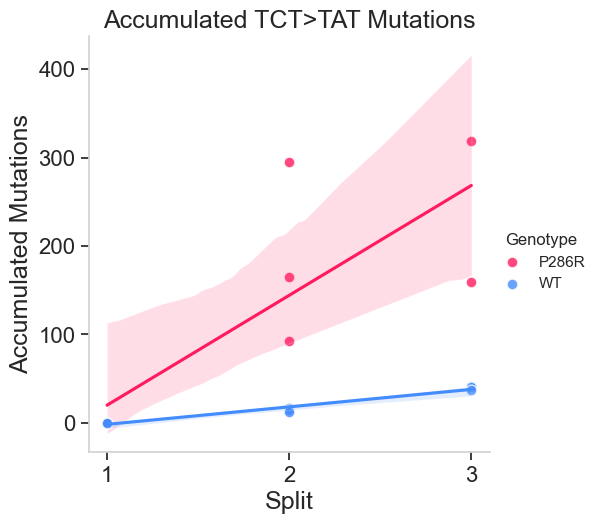

In [109]:
## Plot
g = sns.lmplot(time_series_10a, x='Split',y='Accumulated_Mutations_norm',
               scatter_kws={'s': 60,'edgecolor': 'white'},
               # palette={'WT':'#E8E4F0','P286R':'#FF1B5E'}, #Dark mode
               palette={'WT':'#438CFD','P286R':'#FF1B5E'},
               hue='Genotype'
              )

new_ticks = [0,1,2]
new_labels = ['1','2','3']
g.set(xticks=new_ticks, xticklabels=new_labels)
g.ax.tick_params(labelsize=16)

# g.ax.legend(fontsize=16)
# # or to also control the title:
# leg = g.ax.get_legend()
# leg._legend_title_fontsize = 16
# for text in leg.get_texts():
#     text.set_fontsize(16)

# plt.ylim(-19000,100000)
plt.xlabel("Split", fontsize=18)
plt.ylabel("Accumulated Mutations", fontsize=18)
plt.title("Accumulated TCT>TAT Mutations", fontsize=18)
# plt.setp(g.spines.values(), linewidth=3)
# g.savefig('../results/K562_mut_accumulation/10a_accumulation.png', transparent=True, bbox_inches='tight')
plt.show()

In [112]:
adata.shape

(17, 558148)

In [115]:
adata.layers['DP'].sum(axis=1)/adata.shape[1]

matrix([[32.651726],
        [37.753773],
        [39.64851 ],
        [33.1246  ],
        [36.428627],
        [35.18364 ],
        [35.92149 ],
        [39.06123 ],
        [37.125145],
        [28.19368 ],
        [38.80034 ],
        [36.153248],
        [31.223145],
        [39.42889 ],
        [29.91552 ],
        [37.7958  ],
        [37.64446 ]], dtype=float32)